In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import numpy as np

In [7]:
batch_sizes = (32, 64, 128)
modes = ('onfly', 'preload')
num_iterations = {32: 0, 64: 0, 128: 0} # only for onfly, to be updated

In [8]:
data_dir = os.path.join(os.getcwd(), 'final_data_analysis', 'timing_data')
plot_dir = os.path.join(os.getcwd(), 'final_plots', 'timing')

In [9]:
data_files_backward = glob.glob(os.path.join(data_dir, "backward", "*.csv"))
data_files_forward = glob.glob(os.path.join(data_dir, "forward", "*.csv"))
data_files_optim = glob.glob(os.path.join(data_dir, "optim", "*.csv"))
data_files_step_onfly = glob.glob(os.path.join(data_dir, "step", "*.csv"))

In [10]:
print(f"Number of backward files: {len(data_files_backward)}")
print(f"Number of forward files: {len(data_files_forward)}")
print(f"Number of optimization files: {len(data_files_optim)}")
print(f"Number of training files: {len(data_files_step_onfly)}")

Number of backward files: 18
Number of forward files: 18
Number of optimization files: 18
Number of training files: 9


In [11]:
def get_params_from_filename(file):
    """
    Inputs:
        file: str, full file path
    Outputs:
        batch_size: int
        num_workers: int
        num_samples: int
        repeat: int
    """
    file_name = os.path.basename(file)
    
    batch_size = int(file_name.split("_batch-")[1].split("_work-")[0])
    num_workers = int(file_name.split("_work-")[1].split("_samples-")[0])
    num_samples = int(file_name.split("_samples-")[1].split("_repeat-")[0])
    repeat = int(file_name.split("_repeat-")[1].split("_labels-")[0])
    total_samples = num_samples * repeat
    mode = file_name.split(".csv")[0].split("_")[-1]

    return batch_size, num_workers, total_samples, mode

In [12]:
def create_data_dict(data_files):
    data_dict = {}
    for f in data_files:
        batch_size, num_workers, total_samples, mode = get_params_from_filename(f)
        df = pd.read_csv(f)
        
        # remove first and last data
        df = df.iloc[1:-1]
        
        if (mode, batch_size) in data_dict:
            data_dict[(mode, batch_size)] = pd.concat([data_dict[(mode, batch_size)], df], ignore_index=True)
        
        else:
            data_dict[(mode, batch_size)] = df
        
    return data_dict

Concatenate the dataframes for each batch size and mode

In [13]:
data_dict_backward = create_data_dict(data_files_backward) # {(mode, batch_size): data}
data_dict_forward = create_data_dict(data_files_forward) # {(mode, batch_size): data}
data_dict_optim = create_data_dict(data_files_optim) # {(mode, batch_size): data}
data_dict_step_onfly = create_data_dict(data_files_step_onfly) # {(mode, batch_size): data}

Concatenate the backward, forward, and optim data together in one df for simplicity.

In [14]:
data_dict_phase = {}
for m in modes:
    for b in batch_sizes:
        d_fwd = data_dict_forward[(m, b)]
        d_bwd = data_dict_backward[(m, b)]
        d_optim = data_dict_optim[(m, b)]

        # rename the columns
        d_fwd = d_fwd.rename(columns={"time": "forward_time"})
        d_bwd = d_bwd.rename(columns={"time": "backward_time"})
        d_optim = d_optim.rename(columns={"time": "optim_time"})

        d_all = pd.concat([d_fwd, d_bwd, d_optim], axis=1)
        data_dict_phase[(m, b)] = d_all

In [15]:
data_dict_phase[("onfly", 32)].head()

,forward_time,backward_time,optim_time
0,122241005,289867197,1800444
1,123170388,289333202,2037637
2,122268426,288651251,1741133
3,122883844,289944529,1730493
4,122943295,289729196,1918736


Update the number of iterations

In [16]:
for b in batch_sizes:
    num_iterations[b] = len(data_dict_phase[("onfly", b)])/3 + 2

Calculate the batch creation estimate time.

In [17]:
batch_creation_time_dict = {}
for b in batch_sizes:
    avg_step_time = data_dict_phase[("onfly", b)].mean(axis=0).sum()
    batch_creation_time_dict[("onfly", b)] = (data_dict_step_onfly[("onfly", b)]["time"] - avg_step_time*2)/1e9

In [18]:
# remove the outlier in batch size 32
d = batch_creation_time_dict[("onfly", 32)]
batch_creation_time_dict[("onfly", 32)] = d[d < 10]

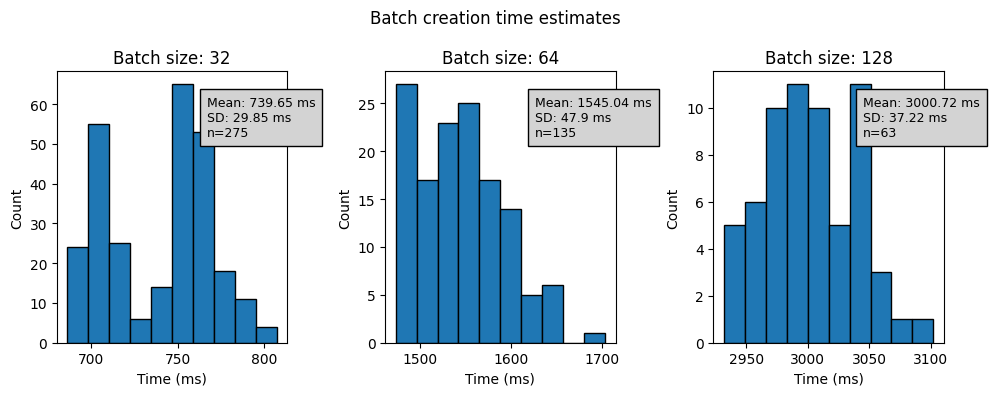

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4), layout="tight")

for i, b in enumerate(batch_sizes):
    data = batch_creation_time_dict[("onfly", b)]*1e3
    ax[i].hist(data, edgecolor="black")
    ax[i].set_title(f"Batch size: {b}")
    ax[i].set_xlabel("Time (ms)")
    ax[i].text(0.65, 0.76, f"Mean: {round(data.mean(), 2)} ms\nSD: {round(data.std(), 2)} ms\nn={len(data)}", transform=ax[i].transAxes,
               fontsize = 9, 
            bbox ={'facecolor':'lightgrey', 
                   'alpha':1, 'pad':5})
    ax[i].set_ylabel("Count")
fig.suptitle("Batch creation time estimates")
fig.savefig(os.path.join(plot_dir,  "batch_gen_time.png"), dpi=300, bbox_inches="tight")

Create the barplot comparing the training times.

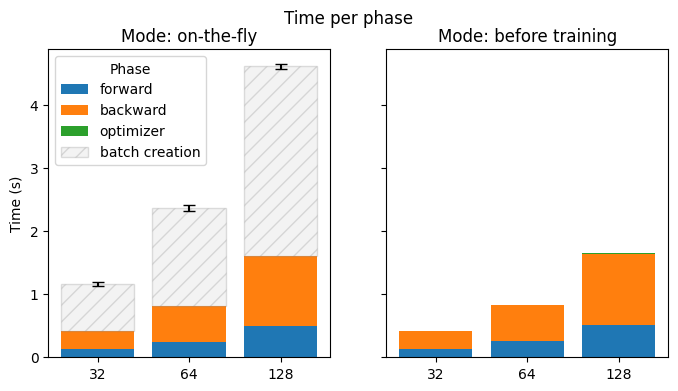

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
label_locs = np.arange(len(batch_sizes))  # the label locations
width = 0.25  # the width of the bars

for i, m in enumerate(modes):
    time_per_batch = {"forward": [],
                  "backward": [],
                  "optimizer": []} # phase: [mean_32, mean_64, mean_128]
    
    std_time_per_batch = {"forward": [],
                  "backward": [],
                  "optimizer": []} # phase: [stdev_32, stdev_64, stdev_128]
    
    for b in batch_sizes:
        data = data_dict_phase[(m, b)]

        # get the mean of the times for each phase for that particular batch size
        time_per_batch["forward"].append(data["forward_time"].mean()/1e9)
        time_per_batch["backward"].append(data["backward_time"].mean()/1e9)
        time_per_batch["optimizer"].append(data["optim_time"].mean()/1e9)

        # get the stdev
        std_time_per_batch["forward"].append(data["forward_time"].std()/1e9)
        std_time_per_batch["backward"].append(data["backward_time"].std()/1e9)
        std_time_per_batch["optimizer"].append(data["optim_time"].std()/1e9)

    bottom = np.zeros(3)

    for component, times in time_per_batch.items():
        bar_data = ax[i].bar(label_locs, times, label=component, bottom=bottom)
        bottom += times
        
    # add the batch creation time to the onfly bar
    if m == "onfly":
        batch_times = []
        batch_times_std = []
        for b in batch_sizes:
            batch_times.append(batch_creation_time_dict[("onfly", b)].mean())
            batch_times_std.append(batch_creation_time_dict[("onfly", b)].std())

        bar_data = ax[i].bar(label_locs, batch_times, label="batch creation", bottom=bottom,
                             yerr = batch_times_std, capsize=4,
                             hatch="//", edgecolor="grey", color="lightgrey", alpha=0.25)
    if m == "onfly":
        ax[i].set_title(f"Mode: on-the-fly")
    else:
        ax[i].set_title(f"Mode: before training")

    ax[i].set_xticks(label_locs, batch_sizes)

ax[0].set_ylabel("Time (s)")
ax[0].legend(title="Phase")
fig.suptitle("Time per phase")
fig.savefig(os.path.join(plot_dir, f"timing_per_phase.png"), dpi=300, bbox_inches="tight")


Get the actual values per phase

In [45]:
time_means_df = pd.DataFrame()
time_std_df = pd.DataFrame()

for b in batch_sizes:
    data_onfly = data_dict_phase[("onfly", b)]
    data_preload = data_dict_phase[("preload", b)]
    d = pd.concat([data_onfly, data_preload])

    # means
    d_mean = d.mean()/1e6
    d_mean["batch size"] = b

    time_means_df = pd.concat([time_means_df, d_mean], axis=1)

    # stdev
    d_std = d.std()/1e6
    d_std["batch size"] = b

    time_std_df = pd.concat([time_std_df, d_std], axis=1)

In [46]:
time_means_df.T

,forward_time,backward_time,optim_time,batch size
0,126.034651,292.882261,1.785534,32.0
0,251.875996,576.081269,1.754001,64.0
0,505.214856,1129.147910,1.793063,128.0


In [47]:
time_std_df.T

,forward_time,backward_time,optim_time,batch size
0,1.718680,3.070771,0.472404,32.0
0,3.263665,6.668862,0.096140,64.0
0,6.407779,12.416733,0.125611,128.0


Get values of batch creation times

In [58]:
time_means_bc_df = pd.DataFrame()
time_std_bc_df = pd.DataFrame()

for b in batch_sizes:
    d = batch_creation_time_dict[("onfly", b)]

    # means
    d_mean = pd.DataFrame({"Mean batch creation time": [d.mean()*1000],
                           "Batch size": [b]})

    time_means_bc_df = pd.concat([time_means_bc_df, d_mean])

    # stdev
    d_std = pd.DataFrame({"STD batch creation time": [d.std()*1000],
                           "Batch size": [b]})

    time_std_bc_df = pd.concat([time_std_bc_df, d_std])

In [ ]:
time_means_bc_df

,Mean batch creation time,Batch size
0,739.650192,32
0,1545.035654,64
0,3000.722057,128


In [61]:
time_std_bc_df

,STD batch creation time,Batch size
0,29.847457,32
0,47.899334,64
0,37.222714,128
